In [4]:
import pandas as pd
import numpy as np


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [6]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

In [7]:
np.random.seed(42)

tf.random.set_seed(42)

In [8]:
print("1. Fetching the real IBM Telco Customer Churn dataset...")

url = "https://raw.githubusercontent.com/carlosfab/dsnp2/master/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

1. Fetching the real IBM Telco Customer Churn dataset...


In [9]:
print("2. Cleaning and preprocessing real data...")
df = df.drop(columns=["customerID"])

2. Cleaning and preprocessing real data...


In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [11]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


In [12]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [13]:
X = pd.get_dummies(X, drop_first=True)


In [14]:
print("3. Splitting data into train, validation, and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

3. Splitting data into train, validation, and test sets...


In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [16]:
print("4. Scaling features...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


4. Scaling features...


In [17]:
print("5. Building the ANN model...")
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])


5. Building the ANN model...


c:\Users\Dell\Documents\c\tensorflow\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [20]:
print("6. Training the model...")
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)



6. Training the model...
Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7587 - loss: 0.4948 - val_accuracy: 0.7822 - val_loss: 0.4510
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7869 - loss: 0.4407 - val_accuracy: 0.7858 - val_loss: 0.4401
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7987 - loss: 0.4285 - val_accuracy: 0.7884 - val_loss: 0.4347
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7998 - loss: 0.4247 - val_accuracy: 0.7920 - val_loss: 0.4312
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8029 - loss: 0.4188 - val_accuracy: 0.7902 - val_loss: 0.4303
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8040 - loss: 0.4153 - val_accuracy: 0.7929 - val_loss: 0.4305
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8042 - loss: 0.4100 - val_accuracy: 0.7902 - val_loss: 0.4311
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8076 

In [21]:
print("\n7. Evaluating the model...")
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs.ravel() > 0.5).astype(int)



7. Evaluating the model...
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [22]:
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Accuracy ---")
print(accuracy_score(y_test, y_pred))


--- Confusion Matrix ---
[[934  99]
 [191 183]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


--- Accuracy ---
0.7938877043354655


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


In [1]:
print("\n7. Calculating Feature Importances...")



7. Calculating Feature Importances...


In [25]:
baseline_preds = (model.predict(X_test, verbose=0).ravel() > 0.5).astype(int)
baseline_acc = accuracy_score(y_test, baseline_preds)


In [26]:
importances = {}

In [27]:
# Permutation Importance
for i, col in enumerate(X.columns):

    # Copy test data
    X_test_permuted = X_test.copy()

    # Shuffle ONE feature column
    X_test_permuted[:, i] = np.random.permutation(X_test_permuted[:, i])

    # Predict with shuffled feature
    permuted_preds = (
        model.predict(X_test_permuted, verbose=0).ravel() > 0.5
    ).astype(int)

    permuted_acc = accuracy_score(y_test, permuted_preds)

    # Importance = accuracy drop
    importances[col] = baseline_acc - permuted_acc


In [28]:
importance_df = pd.DataFrame({
    "Feature": list(importances.keys()),
    "Importance Drop": list(importances.values())
})


In [29]:
importance_df = importance_df.sort_values(
    by="Importance Drop",
    ascending=False
)

Displaying chart...


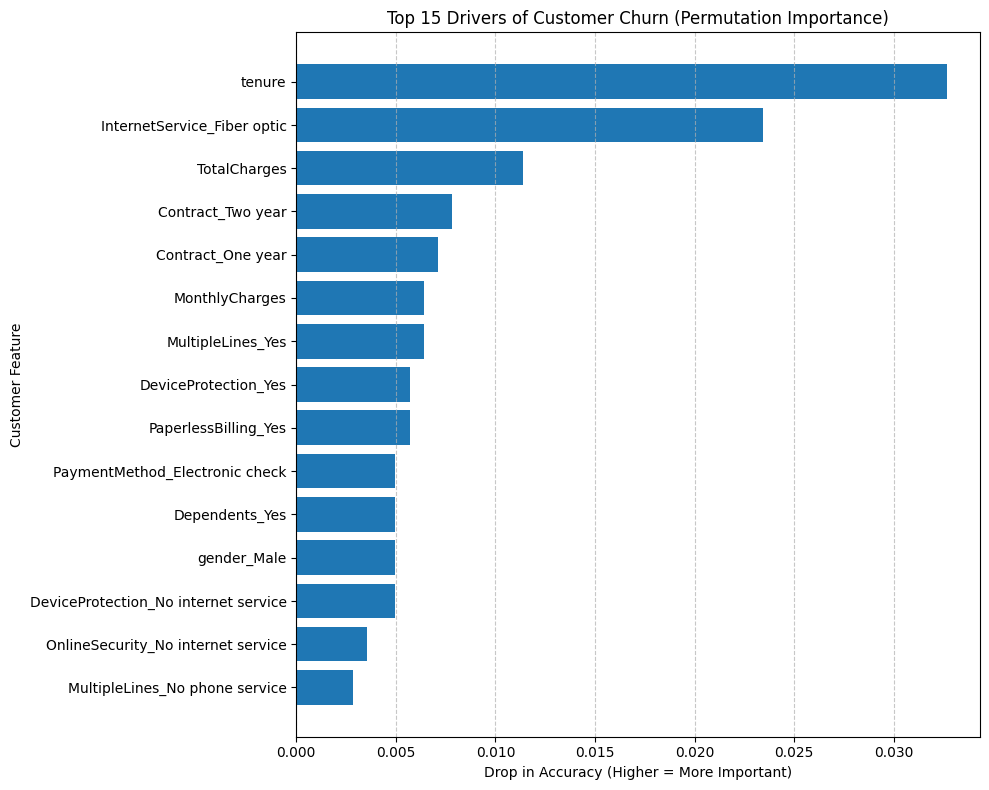

In [30]:
plt.figure(figsize=(10, 8))

top_features = importance_df.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance Drop"][::-1]
)

plt.title("Top 15 Drivers of Customer Churn (Permutation Importance)")
plt.xlabel("Drop in Accuracy (Higher = More Important)")
plt.ylabel("Customer Feature")

plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

print("Displaying chart...")
plt.show()